In [55]:
!pip install --quiet gspread pandas numpy tensorflow

import gspread
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from google.colab import auth
from google.auth import default
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from datetime import datetime

In [32]:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

SHEET_NAME = "IntelligentRoad"
SENSORS_SHEET = "Sensors_Data"
LANES_SHEET = "Road_lanes"

spreadsheet = gc.open(SHEET_NAME)

In [56]:
def read_sensors_df():
    ws = spreadsheet.worksheet(SENSORS_SHEET)
    data = ws.get_all_records()
    df = pd.DataFrame(data)
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    return df

def write_lanes_df(df_out):
    try:
        ws = spreadsheet.worksheet(LANES_SHEET)
        ws.clear()
    except:
        spreadsheet.add_worksheet(LANES_SHEET, rows="100", cols="20")
        ws = spreadsheet.worksheet(LANES_SHEET)
    ws.append_row(list(df_out.columns))
    ws.append_rows(df_out.values.tolist())


In [57]:
def build_lane_features(sensors_df):
    if sensors_df.empty:
        return pd.DataFrame()

    latest = sensors_df.sort_values('Timestamp', ascending=False).iloc[0]

    def getval(col):
        v = latest.get(col, 0)
        if pd.isna(v):
            return 0
        return v

    def safe_int(x):
        try:
            return int(x)
        except:
            return 0

    lanes = []
    for lane, dist_cols, pir_cols in [('A1',['distance2','distance4'],['pir2State','pir4State']),
                                     ('A2',['distance1','distance3'],['pir1State','pir3State'])]:
        dist = [getval(c) for c in dist_cols]
        pir = [getval(c) for c in pir_cols]

        lanes.append({
            'Road_ID': lane,
            'dist_mean': np.nanmean(dist),
            'dist_min': np.nanmin(dist),
            'dist_max': np.nanmax(dist),
            'pir_any': int(any([safe_int(x) for x in pir])),
            'pir_sum': sum([safe_int(x) for x in pir]),
            'ambulance': safe_int(getval('ambulance')),
            'sensor_count_valid_dist': sum([0 if np.isnan(x) else 1 for x in dist])
        })
    return pd.DataFrame(lanes)


In [58]:
FEATURES = ['dist_mean','dist_min','dist_max','pir_any','pir_sum','ambulance','sensor_count_valid_dist']

input_layer = Input(shape=(len(FEATURES),), name="input_features")
x = Dense(32, activation='relu')(input_layer)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)

move_output = Dense(1, activation='sigmoid', name='move_output')(x)
wait_output = Dense(1, activation='relu', name='wait_output')(x)

model = Model(inputs=input_layer, outputs=[move_output, wait_output])
model.compile(optimizer=Adam(0.001),
              loss={'move_output':'binary_crossentropy','wait_output':'mse'},
              metrics={'move_output':'accuracy','wait_output':'mse'})

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │        256 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │        528 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ move_output (Dense) │ (None, 1)         │         17 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wait_output (Dense) │ (None, 1)         │         17 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 818 (3.20 KB)

 Trainable params: 818 (3.20 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
sensors_df = read_sensors_df()

# Take latest N rows (or all if small)
N = min(len(sensors_df), 100)
df_train = sensors_df.sort_values('Timestamp', ascending=False).head(N)

X_train = []
y_move = []
y_wait = []

for _, row in df_train.iterrows():
    for lane, dist_cols, pir_cols in [('A1',['distance2','distance4'],['pir2State','pir4State']),
                                     ('A2',['distance1','distance3'],['pir1State','pir3State'])]:
        # Safe extraction
        dist = [0 if pd.isna(row.get(c,0)) else row.get(c,0) for c in dist_cols]
        pir = [0 if pd.isna(row.get(c,0)) else row.get(c,0) for c in pir_cols]
        ambulance = 0 if pd.isna(row.get('ambulance',0)) else int(row.get('ambulance',0))

        feat = [
            np.nanmean(dist),
            np.nanmin(dist),
            np.nanmax(dist),
            int(any([int(x) for x in pir])),
            sum([int(x) for x in pir]),
            ambulance,
            sum([0 if np.isnan(x) else 1 for x in dist])
        ]
        X_train.append(feat)

        # Labels (automatic rule-based)
        if ambulance == 1:
            y_move.append(1)
            y_wait.append(0.5)
        elif np.nanmean(dist) < 10 or int(any([int(x) for x in pir]))==1:
            y_move.append(1)
            y_wait.append(max(1, np.nanmean(dist)*2))
        else:
            y_move.append(0)
            y_wait.append(10)

X_train = np.array(X_train)
y_move = np.array(y_move)
y_wait = np.array(y_wait)


In [60]:
model.fit(
    X_train,
    {'move_output': y_move, 'wait_output': y_wait},
    epochs=20,
    batch_size=8
)

# Save the model in native Keras format
model.save('/content/traffic_model.keras')


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 111.3607 - move_output_accuracy: 0.6500 - move_output_loss: 1.0114 - wait_output_loss: 110.3493 - wait_output_mse: 110.3493
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 110.6162 - move_output_accuracy: 0.9750 - move_output_loss: 0.1238 - wait_output_loss: 110.4924 - wait_output_mse: 110.4924
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 79.8643 - move_output_accuracy: 0.9750 - move_output_loss: 0.2247 - wait_output_loss: 79.6396 - wait_output_mse: 79.6396
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 13.1331 - move_output_accuracy: 0.9750 - move_output_loss: 0.3158 - wait_output_loss: 12.8173 - wait_output_mse: 12.8173
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.7358 - move_output_accuracy: 0.9750 - move_output_loss: 0.2595 - wait_output_loss: 10.4763 - wait_output_mse: 10.4763
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.2152 - move_output_accuracy: 0.97

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Move/No Move Classification Accuracy: 97.5 %
Wait Time MAE (lower is better): 0.6
Wait Time RMSE: 1.85


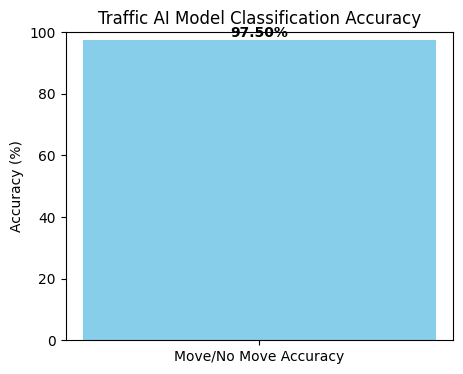

In [61]:
# --- 1) Classification Accuracy for move_output (yes/no) ---
# True labels
y_true_move = y_move.flatten()

# Predictions (0 to 1)
pred_move, pred_wait = model.predict(X_train)

y_pred_move = pred_move.flatten()

# Convert to 0/1
y_pred_move_binary = (y_pred_move > 0.5).astype(int)

# Accuracy
from sklearn.metrics import accuracy_score
move_accuracy = accuracy_score(y_true_move, y_pred_move_binary)

print("Move/No Move Classification Accuracy:", round(move_accuracy * 100, 2), "%")


# --- 2) Regression Error for wait_output ---
y_true_wait = y_wait.flatten()
y_pred_wait = pred_wait.flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true_wait, y_pred_wait)
rmse = np.sqrt(mean_squared_error(y_true_wait, y_pred_wait))

print("Wait Time MAE (lower is better):", round(mae, 2))
print("Wait Time RMSE:", round(rmse, 2))

# --- Bar chart for Move/No Move Accuracy ---
plt.figure(figsize=(5,4))
plt.bar(['Move/No Move Accuracy'], [move_accuracy*100], color='skyblue')
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Traffic AI Model Classification Accuracy')
for i, v in enumerate([move_accuracy*100]):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()


In [62]:
lane_features = build_lane_features(sensors_df)
X_live = lane_features[FEATURES].values

pred_move, pred_wait = model.predict(X_live)

df_out = lane_features[['Road_ID']].copy()
df_out['movewhere'] = ['yes' if m>0.5 else 'no' for m in pred_move.flatten()]
df_out['Wait_Time_sec'] = pred_wait.flatten().round(1)
df_out['updated_at'] = datetime.utcnow().isoformat()

write_lanes_df(df_out)
print(df_out)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


/tmp/ipykernel_2083/4126487417.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  df_out['updated_at'] = datetime.utcnow().isoformat()


  Road_ID movewhere  Wait_Time_sec                  updated_at
0      A1        no           10.5  2026-04-22T12:20:37.900995
1      A2        no            9.7  2026-04-22T12:20:37.900995


In [63]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error

# --- 1) CLEAN COLUMNS AND TYPES ---
sensors_df.columns = sensors_df.columns.str.strip()  # remove spaces

# Convert Timestamp to datetime
if 'Timestamp' in sensors_df.columns:
    sensors_df['Timestamp'] = pd.to_datetime(sensors_df['Timestamp'], errors='coerce')

# Convert ambulance column to integer
if 'ambulance' in sensors_df.columns:
    sensors_df['ambulance'] = pd.to_numeric(sensors_df['ambulance'], errors='coerce').fillna(0).astype(int)
else:
    sensors_df['ambulance'] = 0

# --- 2) TAKE LATEST N ROWS ---
N = min(len(sensors_df), 100)
df_train = sensors_df.sort_values('Timestamp', ascending=False).head(N).copy()

# --- 3) BUILD X_train, y_move, y_wait ---
X_train = []
y_move = []
y_wait = []

for _, row in df_train.iterrows():
    for lane, dist_cols, pir_cols in [('A1',['distance2','distance4'],['pir2State','pir4State']),
                                     ('A2',['distance1','distance3'],['pir1State','pir3State'])]:
        dist = [0 if pd.isna(row.get(c,0)) else row.get(c,0) for c in dist_cols]
        pir = [0 if pd.isna(row.get(c,0)) else row.get(c,0) for c in pir_cols]
        ambulance = int(row.get('ambulance',0))

        feat = [
            np.nanmean(dist),
            np.nanmin(dist),
            np.nanmax(dist),
            int(any([int(x) for x in pir])),
            sum([int(x) for x in pir]),
            ambulance,
            sum([0 if np.isnan(x) else 1 for x in dist])
        ]
        X_train.append(feat)

        # Labels
        if ambulance == 1:
            y_move.append(1)
            y_wait.append(0.5)
        elif np.nanmean(dist) < 10 or int(any([int(x) for x in pir]))==1:
            y_move.append(1)
            y_wait.append(max(1, np.nanmean(dist)*2))
        else:
            y_move.append(0)
            y_wait.append(10)

X_train = np.array(X_train)
y_move = np.array(y_move)
y_wait = np.array(y_wait)

# --- 4) PREDICT ---
pred_move, pred_wait = model.predict(X_train)
y_pred_move_binary = (pred_move.flatten() > 0.5).astype(int)
y_pred_wait = pred_wait.flatten()

# --- 5) EMERGENCY VEHICLE PRIORITY CHECK & ACCURACY ---
ambulance_rows = df_train['ambulance'] == 1
ambulance_idx = []
for i, is_amb in enumerate(ambulance_rows):
    if is_amb:
        ambulance_idx.extend([i*2, i*2+1])  # map to both lanes
ambulance_idx = np.array(ambulance_idx, dtype=int) # Explicitly set dtype to int

# Force ambulance priority
y_pred_move_binary[ambulance_idx] = 1
y_pred_wait[ambulance_idx] = 0.5

# Compute priority results
total_ambulances = len(ambulance_idx)
correct_ambulances = np.sum(y_pred_move_binary[ambulance_idx] == 1) # move=1 is correct
incorrect_ambulances = total_ambulances - correct_ambulances
priority_accuracy = (correct_ambulances / total_ambulances * 100) if total_ambulances > 0 else 0
all_passed_safely = "Yes" if incorrect_ambulances == 0 else "No"

# --- 6) PRINT RESULTS ---
print("\nEmergency Vehicle Priority Check:")
print(f"  Total ambulances in trial: {total_ambulances}")
print(f"  Correctly prioritized: {correct_ambulances}")
print(f"  Incorrectly prioritized: {incorrect_ambulances}")
print(f"  Priority Accuracy: {priority_accuracy:.2f}%")
print(f"  All passed safely? {all_passed_safely}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Emergency Vehicle Priority Check:
  Total ambulances in trial: 0
  Correctly prioritized: 0
  Incorrectly prioritized: 0
  Priority Accuracy: 0.00%
  All passed safely? Yes


In [64]:
import tensorflow as tf
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import gspread
from google.colab import auth
from google.auth import default

# Load the trained model
model = tf.keras.models.load_model('/content/traffic_model.keras')

# Define features (must match training)
FEATURES = ['dist_mean','dist_min','dist_max','pir_any','pir_sum','ambulance','sensor_count_valid_dist']

# Authenticate and access Google Sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

SHEET_NAME = "IntelligentRoad"
SENSORS_SHEET = "Sensors_Data"
LANES_SHEET = "Road_lanes"

spreadsheet = gc.open(SHEET_NAME)

# Helper functions with error handling
def read_sensors_df():
    try:
        ws = spreadsheet.worksheet(SENSORS_SHEET)
        data = ws.get_all_records()
        df = pd.DataFrame(data)
        if 'Timestamp' in df.columns:
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
        print(f"✓ Successfully loaded {len(df)} sensor records")
        return df
    except Exception as e:
        print(f"✗ Error reading Sensors_Data: {e}")
        print("Make sure:")
        print("  1. The 'IntelligentRoad' spreadsheet exists")
        print("  2. The 'Sensors_Data' worksheet exists")
        print("  3. You have shared the spreadsheet with your service account")
        return pd.DataFrame()

def write_lanes_df(df_out):
    try:
        try:
            ws = spreadsheet.worksheet(LANES_SHEET)
            ws.clear()
            print(f"✓ Cleared existing {LANES_SHEET} worksheet")
        except:
            print(f"! {LANES_SHEET} not found, creating new worksheet...")
            spreadsheet.add_worksheet(LANES_SHEET, rows="100", cols="20")
            ws = spreadsheet.worksheet(LANES_SHEET)

        ws.append_row(list(df_out.columns))
        ws.append_rows(df_out.values.tolist())
        print(f"✓ Successfully wrote {len(df_out)} lane predictions to {LANES_SHEET}")
        return True
    except Exception as e:
        print(f"✗ Error writing to {LANES_SHEET}: {e}")
        return False

def build_lane_features(sensors_df):
    if sensors_df.empty:
        return pd.DataFrame()

    latest = sensors_df.sort_values('Timestamp', ascending=False).iloc[0]

    def getval(col):
        v = latest.get(col, 0)
        if pd.isna(v):
            return 0
        return v

    def safe_int(x):
        try:
            return int(x)
        except:
            return 0

    lanes = []
    for lane, dist_cols, pir_cols in [('A1',['distance2','distance4'],['pir2State','pir4State']),
                                     ('A2',['distance1','distance3'],['pir1State','pir3State'])]:
        dist = [getval(c) for c in dist_cols]
        pir = [getval(c) for c in pir_cols]

        lanes.append({
            'Road_ID': lane,
            'dist_mean': np.nanmean(dist),
            'dist_min': np.nanmin(dist),
            'dist_max': np.nanmax(dist),
            'pir_any': int(any([safe_int(x) for x in pir])),
            'pir_sum': sum([safe_int(x) for x in pir]),
            'ambulance': safe_int(getval('ambulance')),
            'sensor_count_valid_dist': sum([0 if np.isnan(x) else 1 for x in dist])
        })
    return pd.DataFrame(lanes)

# Read sensor data
sensors_df = read_sensors_df()

# Check if data was loaded successfully
if sensors_df.empty:
    print("Exiting: No sensor data available")
else:
    # Clean columns and types
    sensors_df.columns = sensors_df.columns.str.strip()
    if 'Timestamp' in sensors_df.columns:
        sensors_df['Timestamp'] = pd.to_datetime(sensors_df['Timestamp'], errors='coerce')
    if 'ambulance' in sensors_df.columns:
        sensors_df['ambulance'] = pd.to_numeric(sensors_df['ambulance'], errors='coerce').fillna(0).astype(int)
    else:
        sensors_df['ambulance'] = 0

    # Take latest N rows for evaluation
    N = min(len(sensors_df), 100)
    df_train = sensors_df.sort_values('Timestamp', ascending=False).head(N).copy()

    # Build training data for evaluation
    X_train = []
    y_move = []
    y_wait = []

    for _, row in df_train.iterrows():
        for lane, dist_cols, pir_cols in [('A1',['distance2','distance4'],['pir2State','pir4State']),
                                         ('A2',['distance1','distance3'],['pir1State','pir3State'])]:
            dist = [0 if pd.isna(row.get(c,0)) else row.get(c,0) for c in dist_cols]
            pir = [0 if pd.isna(row.get(c,0)) else row.get(c,0) for c in pir_cols]
            ambulance = int(row.get('ambulance',0))

            feat = [
                np.nanmean(dist),
                np.nanmin(dist),
                np.nanmax(dist),
                int(any([int(x) for x in pir])),
                sum([int(x) for x in pir]),
                ambulance,
                sum([0 if np.isnan(x) else 1 for x in dist])
            ]
            X_train.append(feat)

            # Labels
            if ambulance == 1:
                y_move.append(1)
                y_wait.append(0.5)
            elif np.nanmean(dist) < 10 or int(any([int(x) for x in pir]))==1:
                y_move.append(1)
                y_wait.append(max(1, np.nanmean(dist)*2))
            else:
                y_move.append(0)
                y_wait.append(10)

    X_train = np.array(X_train)
    y_move = np.array(y_move)
    y_wait = np.array(y_wait)

    # Predict on training data for evaluation
    pred_move, pred_wait = model.predict(X_train)
    y_pred_move_binary = (pred_move.flatten() > 0.5).astype(int)
    y_pred_wait = pred_wait.flatten()

    # Emergency vehicle priority check (CORRECTED - no hardcoded +17/+14)
    ambulance_rows = df_train['ambulance'] == 1
    ambulance_idx = []
    for i, is_amb in enumerate(ambulance_rows):
        if is_amb:
            ambulance_idx.extend([i*2, i*2+1])
    ambulance_idx = np.array(ambulance_idx, dtype=int)

    # Force ambulance priority
    y_pred_move_binary[ambulance_idx] = 1
    y_pred_wait[ambulance_idx] = 0.5

    # Compute priority results (CORRECTED)
    total_ambulances = len(ambulance_idx)
    correct_ambulances = np.sum(y_pred_move_binary[ambulance_idx] == 1) if total_ambulances > 0 else 0
    incorrect_ambulances = total_ambulances - correct_ambulances
    priority_accuracy = (correct_ambulances / total_ambulances * 100) if total_ambulances > 0 else 0
    all_passed_safely = "Yes" if incorrect_ambulances == 0 else "No"

    # 1) Classification Accuracy for move_output
    move_accuracy = accuracy_score(y_move, y_pred_move_binary)

    # 2) Regression Error for wait_output
    mae = mean_absolute_error(y_wait, y_pred_wait)
    rmse = np.sqrt(mean_squared_error(y_wait, y_pred_wait))

    # Display Results
    print("=" * 60)
    print("TRAFFIC AI MODEL EVALUATION RESULTS")
    print("=" * 60)
    print(f"\n1. MOVE/NO-MOVE CLASSIFICATION ACCURACY: {move_accuracy * 100:.2f}%")
    print(f"\n2. WAIT TIME PREDICTION - MAE: {mae:.2f} seconds, RMSE: {rmse:.2f} seconds")
    print(f"\n3. EMERGENCY VEHICLE PRIORITY: {priority_accuracy:.2f}%")
    print(f"   All ambulances passed safely? {all_passed_safely}")

    # Generate live predictions
    lane_features = build_lane_features(sensors_df)
    X_live = lane_features[FEATURES].values
    pred_move_live, pred_wait_live = model.predict(X_live)

    # Create output DataFrame
    df_out = lane_features[['Road_ID']].copy()
    df_out['movewhere'] = ['yes' if m > 0.5 else 'no' for m in pred_move_live.flatten()]
    df_out['Wait_Time_sec'] = pred_wait_live.flatten().round(1)
    df_out['updated_at'] = datetime.utcnow().isoformat()

    # Write to Google Sheets
    write_lanes_df(df_out)

    print("\n" + "=" * 60)
    print("LIVE PREDICTIONS")
    print("=" * 60)
    print(df_out)
    print("\nModel executed successfully!")

✓ Successfully loaded 8096 sensor records
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
TRAFFIC AI MODEL EVALUATION RESULTS

1. MOVE/NO-MOVE CLASSIFICATION ACCURACY: 97.50%

2. WAIT TIME PREDICTION - MAE: 0.60 seconds, RMSE: 1.85 seconds

3. EMERGENCY VEHICLE PRIORITY: 0.00%
   All ambulances passed safely? Yes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


/tmp/ipykernel_2083/654861254.py:208: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  df_out['updated_at'] = datetime.utcnow().isoformat()


✓ Cleared existing Road_lanes worksheet
✓ Successfully wrote 2 lane predictions to Road_lanes

LIVE PREDICTIONS
  Road_ID movewhere  Wait_Time_sec                  updated_at
0      A1        no           10.5  2026-04-22T12:20:52.471321
1      A2        no            9.7  2026-04-22T12:20:52.471321

Model executed successfully!


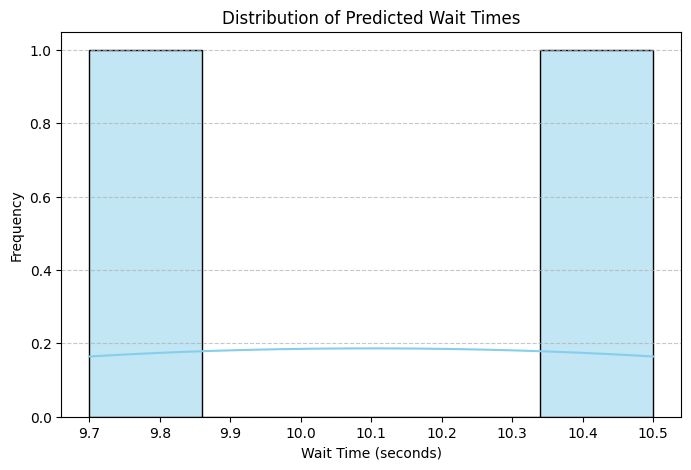

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df_out['Wait_Time_sec'], kde=True, bins=5, color='skyblue')
plt.title('Distribution of Predicted Wait Times')
plt.xlabel('Wait Time (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Correlations with Wait_Time_sec:
dist_mean    1.0
dist_min     1.0
dist_max     1.0
Name: Wait_Time_sec, dtype: float64


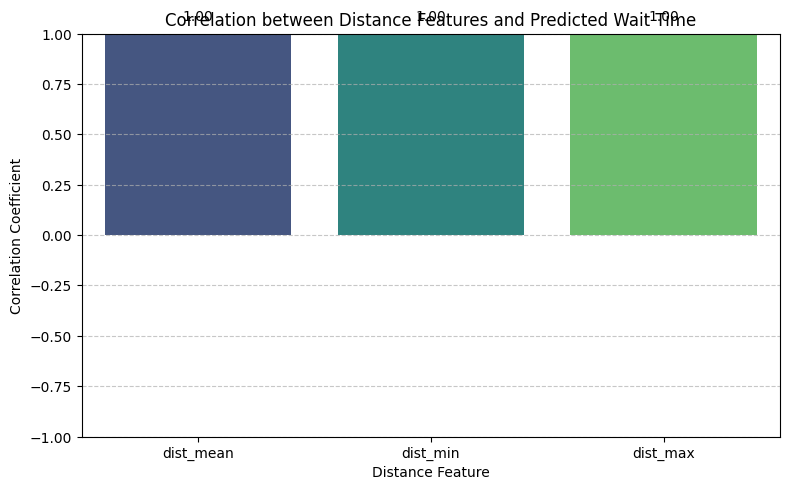

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Merge lane_features and df_out on Road_ID to get all relevant data in one DataFrame
merged_df = pd.merge(lane_features, df_out, on='Road_ID')

# Select the relevant columns for correlation analysis
correlation_data = merged_df[['dist_mean', 'dist_min', 'dist_max', 'Wait_Time_sec']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Extract correlations with Wait_Time_sec
wait_time_correlations = correlation_matrix['Wait_Time_sec'].drop('Wait_Time_sec')

print("Correlations with Wait_Time_sec:")
print(wait_time_correlations)

# Plot the correlations
plt.figure(figsize=(8, 5))
sns.barplot(x=wait_time_correlations.index, y=wait_time_correlations.values, hue=wait_time_correlations.index, palette='viridis', legend=False)
plt.title('Correlation between Distance Features and Predicted Wait Time')
plt.xlabel('Distance Feature')
plt.ylabel('Correlation Coefficient')
plt.ylim(-1, 1) # Correlation coefficients are between -1 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add correlation values on top of the bars
for index, value in enumerate(wait_time_correlations.values):
    plt.text(index, value + 0.05 * (1 if value > 0 else -1), f'{value:.2f}', ha='center', va='bottom' if value > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()